Machine Learning Project
Insurance Cost Prediction & Patient

Readmission Analysis


# Q1. Predictive Modeling of Insurance Costs

# Scenario:

You are a data analyst at a major health insurance company. Your manager has tasked you with building a predictive model to estimate the yearly medical charges for new customers based on their demographic and health information. A simple, interpretable model is required to understand which factors drive costs the most. You have been provided with the insurance.csv dataset.


**Part 1: Data Preparation and Exploration**

 Load the **insurance.csv** dataset into a Pandas DataFrame. Display the data types of each column and confirm that there are no missing values.

In [ ]:
# import all required libararies
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [2]:
df_insurance = pd.read_csv('insurance.csv')
print("--- Data Types ---")
print(df_insurance.dtypes)
print("\n--- Missing Values ---")
print(df_insurance.isnull().sum())

--- Data Types ---
age           int64
sex             str
bmi         float64
children      int64
smoker          str
region          str
expenses    float64
dtype: object

--- Missing Values ---
age         0
sex         0
bmi         0
children    0
smoker      0
region      0
expenses    0
dtype: int64


 The LinearRegression model requires all features to be numerical. Create a new DataFrame where the categorical columns (sex, smoker, region) are converted to numerical format using one-hot encoding.



In [3]:
df_insurance_encoded = pd.get_dummies(df_insurance, columns=['sex', 'smoker', 'region'], drop_first=True)
print(df_insurance_encoded.head())

   age   bmi  children  expenses  sex_male  smoker_yes  region_northwest  \
0   19  27.9         0  16884.92     False        True             False   
1   18  33.8         1   1725.55      True       False             False   
2   28  33.0         3   4449.46      True       False             False   
3   33  22.7         0  21984.47      True       False              True   
4   32  28.9         0   3866.86      True       False              True   

   region_southeast  region_southwest  
0             False              True  
1              True             False  
2              True             False  
3             False             False  
4             False             False  


 Generate a correlation heatmap for your preprocessed data. In a brief written statement (1-2 sentences), identify the single feature that has the strongest correlation with the target variable, expences.



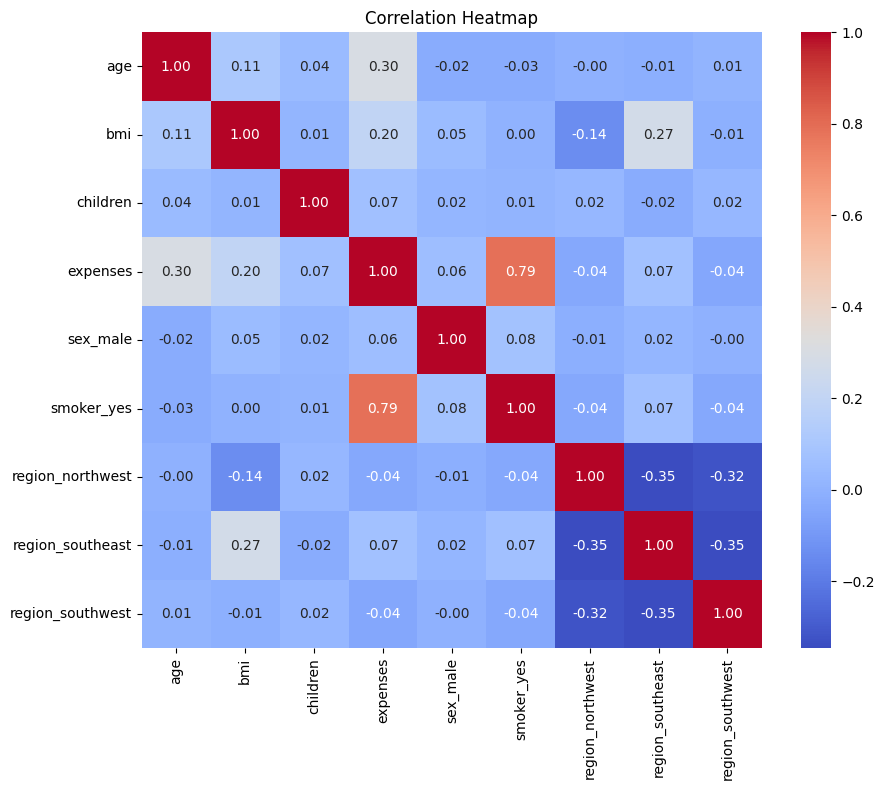

In [4]:
plt.figure(figsize=(10, 8))
sns.heatmap(df_insurance_encoded.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap')
plt.show()

brief statement--The smoker_yes feature has the strongest positive correlation with expenses, indicating that smokers tend to have significantly higher medical costs. 

**Part 2: Model Training and Evaluation**

Separate your data into a feature matrix X (all columns except expenses) and a target vector y (expenses). Split this data into a training set (80%) and a testing set (20%). Use random_state=42 to ensure your results are reproducible.



In [5]:
X = df_insurance_encoded.drop(columns=['expenses'])
y = df_insurance_encoded['expenses']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)

X_train shape: (1070, 8)
X_test shape: (268, 8)


Instantiate and train a LinearRegression model using your training data.



In [6]:
model = LinearRegression()
model.fit(X_train, y_train)



,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](8,)","[ 256.96, 337.27, 425.64,...,-370.31,-658.71,-809.23]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](8,)","['age','bmi','children',...,'region_northwest','region_southeast', 'region_southwest']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,-1.194e+04
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,8
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int,8


Evaluate your trained model on the test set. Calculate and report the following two metrics:

*   R-squared (R²)

*   Root Mean Squared Error (RMSE)

In [7]:
y_pred = model.predict(X_test)
r2 = r2_score(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print("R-squared (R²):", r2)
print("Root Mean Squared Error (RMSE):", rmse)

R-squared (R²): 0.7835726930039906
Root Mean Squared Error (RMSE): 5796.556335884075


 Briefly explain what each of these metrics tells you about your model's performance in the context of this problem (i.e., predicting dollar amounts).

Explanation--

--R-squared : It indicates that approximately 78.36 % of the variance in yearly medical expenses can be explained by the model's features (age, BMI, smoking status, etc.).

--Root Mean Squared Error (RMSE): It measures the average deviation of the model's predictions from the actual values. In this context it shows that the model's expense predictions are off by an average of about $5,796.56

**Part 3: Model Interpretation and Insights**

 A key benefit of linear regression is its interpretability. Display the model's coefficients for each feature.



In [8]:
coefficients = pd.DataFrame({'Feature': X.columns, 'Coefficient': model.coef_})
print(coefficients)

            Feature   Coefficient
0               age    256.955959
1               bmi    337.271473
2          children    425.641376
3          sex_male    -18.519741
4        smoker_yes  23650.312302
5  region_northwest   -370.313511
6  region_southeast   -658.712382
7  region_southwest   -809.229878


Based on the coefficients from your model, answer the following questions:

a)Identify the single most impactful feature for predicting medical charges. How much does this feature increase the predicted yearly charge, holding all other factors constant?

b) Your manager asks, "What's the financial impact of each additional year of a customer's age on their predicted medical costs?" Provide a clear, one-sentence answer based on your model's coefficients.

Answer--
a) The single most impactful feature for predicting medical charges is being a smoker (smoker_yes). Holding all other factors constant, this feature increases the predicted yearly medical charge by approximately $23,650.31.

b) For each additional year of a customer's age, their predicted medical costs increase by approximately $256.96, holding all other factors constant.

# Q2. Predicting Patient Readmission

# Scenario:

You are a data scientist at a hospital network, and you've been tasked with helping doctors identify patients at high risk of being readmitted to the hospital within 30 days of discharge. Early identification can help the hospital provide post-discharge support and reduce readmissions. You have been provided with a simplified diabetes_readmission.csv dataset containing patient attributes.

Your Goal:

Build and evaluate a Logistic Regression model to classify whether a patient will be readmitted (readmitted = 1) or not (not readmitted = 0).

Dataset:

diabetes_readmission.csv

Part 1:

Data Preparation and Exploratory Analysis

Load the diabetes_readmission.csv dataset into a Pandas DataFrame. Verify the data types and check for any missing values.




In [9]:
df_diab = pd.read_csv('diabetes_readmission.csv')
print("--- Data Types ---")
print(df_diab.dtypes)
print("\n--- Missing Values ---")
print(df_diab.isnull().sum())

--- Data Types ---
time_in_hospital      int64
num_lab_procedures    int64
num_medications       int64
age                   int64
readmitted            int64
dtype: object

--- Missing Values ---
time_in_hospital      0
num_lab_procedures    0
num_medications       0
age                   0
readmitted            0
dtype: int64


 Before building a model, it is crucial to understand the distribution of the target variable. Create a bar plot to visualize the number of patients in each class (readmitted = 0 vs. readmitted = 1). Is this an imbalanced dataset? Briefly explain your answer.



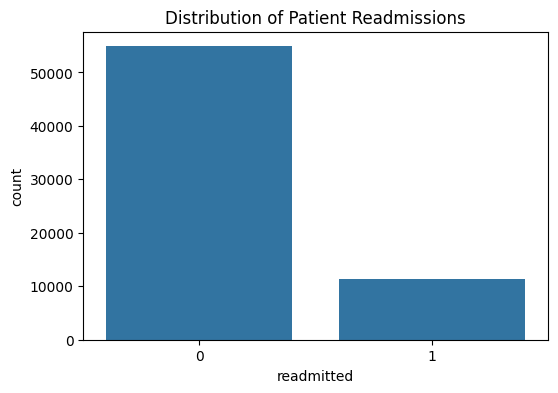

readmitted
0    54864
1    11357
Name: count, dtype: int64


In [10]:
plt.figure(figsize=(6, 4))
sns.countplot(x='readmitted', data=df_diab)
plt.title('Distribution of Patient Readmissions')
plt.show()

print(df_diab['readmitted'].value_counts())

Observation-- The dataset is imbalanced because the number of patients is one class is significantly higher than the other class.

Since logistic regression is sensitive to the scale of features, it is best practice to scale the data. Use StandardScaler to scale the feature matrix X.



In [11]:
X = df_diab.drop(columns=['readmitted'])
y = df_diab['readmitted']

scaler = StandardScaler()

Part 2:

Model Training and Performance Evaluation

Separate your data into a feature matrix X and a target vector y. Split this data into a training set (80%) and a testing set (20%). Use random_state=42. Important: Apply the StandardScaler you prepared in step 3 to transform your training and test sets.


In [12]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("X_train_scaled shape:", X_train_scaled.shape)
print("X_test_scaled shape:", X_test_scaled.shape)

X_train_scaled shape: (52976, 4)
X_test_scaled shape: (13245, 4)


Instantiate and train a LogisticRegression model using your scaled training data. Use random_state=42 for the model as well.





In [13]:
model_classifier = LogisticRegression(random_state=42)
model_classifier.fit(X_train_scaled, y_train)


,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",42
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solve

A key part of classification is choosing the right evaluation metrics. For your model's predictions on the test set, calculate and display the following:

a) Accuracy Score: What is the overall correctness of the model?

b) Confusion Matrix: Display the confusion matrix.

c) Classification Report: Display the full classification report which includes precision, recall, and F1-score for each class.

In [14]:
y_pred = model_classifier.predict(X_test_scaled)

print("a) Accuracy Score:", accuracy_score(y_test, y_pred))
print("\nb) Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nc) Classification Report:\n", classification_report(y_test, y_pred))

a) Accuracy Score: 0.8246885617214043

b) Confusion Matrix:
 [[10923     0]
 [ 2322     0]]

c) Classification Report:
               precision    recall  f1-score   support

           0       0.82      1.00      0.90     10923
           1       0.00      0.00      0.00      2322

    accuracy                           0.82     13245
   macro avg       0.41      0.50      0.45     13245
weighted avg       0.68      0.82      0.75     13245



c:\Users\sures\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\sures\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\sures\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(ave

Part 3:

Interpretation and Business Application

Based on the classification report from Part 2, answer the following:

a) What is the model's recall for the positive class (readmitted = 1)?

b) In the context of this hospital problem, is it more important to have high precision or high recall for the positive class? Justify your choice by explaining the real-world consequence of a false positive versus a false negative.



Answer--



a)  The recall for the positive class (readmitted = 1) is 0.00. This means the model failed to correctly identify any patients who were actually readmitted.


b) In this hospital context, it is more important to have high recall for the positive class.

1) Real-world consequence of a False Negative: A high-risk patient who needs help is predicted as safe and discharged without post-discharge support. This could lead to severe medical complications or health emergencies, which is dangerous for the patient.

2) Real-world consequence of a False Positive: A safe patient is predicted as high-risk, resulting in a "false alarm." The hospital might spend extra resources or provide unnecessary checkups, which only leads to a manageable operational cost but doesn't endanger anyone's life.
Therefore, minimizing False Negatives (achieving high recall) is far more critical to ensure patient safety.

 The hospital wants to use your model to create a "high-risk" watch list. To be extremely confident that a patient on the list is truly high-risk (i.e., to minimize false alarms), you need to adjust the model's decision threshold.

Briefly explain whether you would increase or decrease the default 0.5 probability threshold to achieve higher precision.

Explanation-

-- To achieve higher precision and reduce false alarms, the decision threshold should be increased above the default value of 0.5. A higher threshold makes the model classify a patient as high-risk only when it is more confident, thereby reducing false positives.